In [37]:
# Importando as bibliotecas que usaremos no projeto.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
# Carregando o dataset e visualizando as primeiras linhas.
df = pd.read_csv("data/Coffee Shop Sales.csv")
print("Primeiras 5 linhas do dataset:")
df.head()

Primeiras 5 linhas do dataset:


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [39]:
print("Informações do Dataset:")
df.info()

Informações do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 12.5 MB


In [40]:
print(f"Quantidade de linhas do dataset: {df.shape[0]}")
print(f"Quantidade de colunas do dataset: {df.shape[1]}")

Quantidade de linhas do dataset: 149116
Quantidade de colunas do dataset: 11


In [41]:
informacoes_adicionais = pd.DataFrame({
    "nulos" : df.isnull().sum(),
    "valores_unicos" : df.nunique()
})
print(f"Informações adicionais do dataset:\n{informacoes_adicionais}")

Informações adicionais do dataset:
                  nulos  valores_unicos
transaction_id        0          149116
transaction_date      0             181
transaction_time      0           25762
transaction_qty       0               6
store_id              0               3
store_location        0               3
product_id            0              80
unit_price            0              41
product_category      0               9
product_type          0              29
product_detail        0              80


In [42]:
print("Estatísticas descritivas do dataset:")
df.describe().round(2)

Estatísticas descritivas do dataset:


,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,1.44,5.34,47.92,3.38
std,43153.60,0.54,2.07,17.93,2.66
min,1.00,1.00,3.00,1.00,0.80
25%,37335.75,1.00,3.00,33.00,2.50
50%,74727.50,1.00,5.00,47.00,3.00
75%,112094.25,2.00,8.00,60.00,3.75
max,149456.00,8.00,8.00,87.00,45.00


In [43]:
# Criando a coluna de receita (revenue) multiplicando a quantidade de transações pelo preço unitário.
df['revenue'] = df['transaction_qty'] * df['unit_price']


In [44]:
# Agrupando os dados por data da transação e calculando o total de transações e receita total por dia.
df_diario = df.groupby(['transaction_date', 'store_location']).agg(
        transacoes_totais = ('transaction_id', 'nunique'),
    receita_total = ('revenue', 'sum')
).reset_index()


In [45]:
df_diario.head()

,transaction_date,store_location,transacoes_totais,receita_total
0,1/1/23,Astoria,190,868.40
1,1/1/23,Hell's Kitchen,184,851.45
2,1/1/23,Lower Manhattan,176,788.35
3,1/10/23,Astoria,210,947.00
4,1/10/23,Hell's Kitchen,189,808.10


In [46]:
df_diario.tail()

,transaction_date,store_location,transacoes_totais,receita_total
538,6/8/23,Hell's Kitchen,448,2028.11
539,6/8/23,Lower Manhattan,407,1954.80
540,6/9/23,Astoria,341,1518.48
541,6/9/23,Hell's Kitchen,491,2189.60
542,6/9/23,Lower Manhattan,392,2159.08


In [47]:
# Complementando as estatísticas descritivas do dataset diário com a amplitude.
resumo = df_diario.describe().round(2)
resumo.loc['amplitude'] = resumo.loc['max'] - resumo.loc['min']
print(f"Estatísticas descritivas do dataset diário:\n{resumo}")

Estatísticas descritivas do dataset diário:
           transacoes_totais  receita_total
count                 543.00         543.00
mean                  274.62        1286.95
std                    88.13         430.80
min                   135.00         604.20
25%                   202.00         929.68
50%                   257.00        1165.33
75%                   347.00        1611.43
max                   498.00        2546.43
amplitude             363.00        1942.23


In [48]:
print(f"Quantidade de linhas do dataset: {df_diario.shape[0]}")
print(f"Quantidade de colunas do dataset: {df_diario.shape[1]}")

Quantidade de linhas do dataset: 543
Quantidade de colunas do dataset: 4


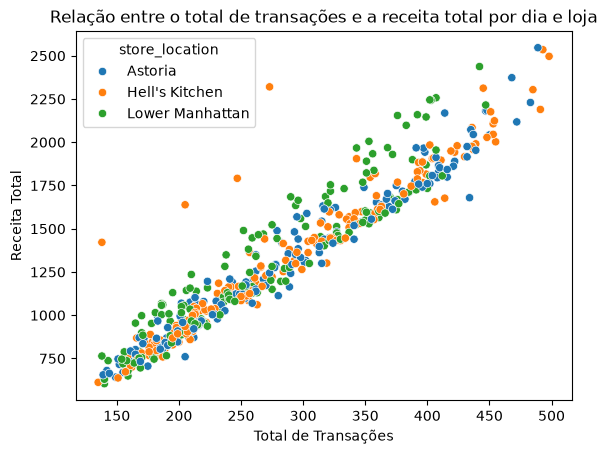

In [49]:
# Visualizando a relação entre o total de transações e a receita total por dia.
sns.scatterplot(data = df_diario,
                 x = 'transacoes_totais',
                   y = 'receita_total',
                   hue = 'store_location'
                   
)
plt.title("Relação entre o total de transações e a receita total por dia e loja")
plt.xlabel("Total de Transações")
plt.ylabel("Receita Total")
plt.show()

In [50]:
''' Para verificar o motivo da dispersão vertical de Hell's Kitchen, vou testar as duas hipóteses abaixo.
Hipótese 1: A dispersão vertical de Hell's Kitchen é causada por uma quantidade maior de produtos comprados por pedido.
Hipótese 2: A dispersão vertical de Hell's Kitchen é causada pela compra de produtos mais caros por pedido.

'''
df_hipotese = df.groupby(['store_location']).agg(
    quantidade_comprada = ('transaction_qty', 'mean'),
    preco_do_produto = ('unit_price', 'mean')
).reset_index()
df_hipotese.head()

,store_location,quantidade_comprada,preco_do_produto
0,Astoria,1.403012,3.384897
1,Hell's Kitchen,1.413955,3.394218
2,Lower Manhattan,1.501444,3.366643


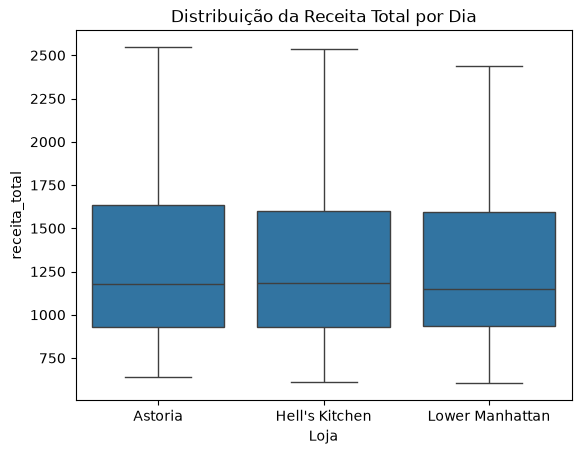

In [51]:
# Visualizando a distribuição da receita total por dia.
sns.boxplot(data = df_diario,
            x = 'store_location',
             y = 'receita_total'
            )

plt.title("Distribuição da Receita Total por Dia")
plt.xlabel("Loja")
plt.show()

Após analisar o gráfico de dispersão de cada loja separadamente, nota-se que a dispersão vertical da loja em Hell’s Kitchen é maior do que as outras duas lojas. Com isso podemos testar duas hipóteses: a dispersão vertical poderia ser justificada por uma quantidade de produtos comprados maior por pedido ou por um valor maior por produto comprado por pedido. 
Por uma limitação da base de dados, que não identifica todos os produtos comprados por um pedido e sim a quantidade de produtos comprados por pedido, a média da quantidade de produtos comprados, assim como o preço dos produtos comprados é comprovadamente sem diferença estatística. Concluindo que a alta variância é causada por um maior fluxo diário de pessoas. 

O diagrama de caixa nos mostra que não possuímos outliers. Sendo assim a operação das lojas supre muito bem os choques de demanda e torna o budget altamente previsível. Além da facilidade na compra de insumos e de escala de funcionários.

Vemos também que apesar de termos a mediana sendo puxada para baixo na loja de Lower Manhattan, a distância entre a mediana e o terceiro quartil é muito maior do que a distância entre a mediana e o primeiro quartil. 
Essa informação nos mostra que os dias com maior faturamento tem uma elasticidade grande, enquanto os dias “normais” ou “ruins” tem uma rigidez maior. O que torna muito mais previsível saber qual será o menor valor faturado possível por dia. 



In [52]:
# Criando uma amostra aleatória de 181 dias do dataset diário para análise estatística.
df_amostra = df_diario.sample(n = 181, random_state = 42)
df_amostra.head()

,transaction_date,store_location,transacoes_totais,receita_total
530,6/5/23,Lower Manhattan,348,1537.00
478,6/17/23,Hell's Kitchen,273,2320.10
354,4/8/23,Astoria,316,1631.93
531,6/6/23,Astoria,313,1397.10
322,4/25/23,Hell's Kitchen,266,1284.55


In [53]:
# Métricas estatísticas da amostra
df_amostra_media = df_amostra['receita_total'].mean().round(2)
print(f"Média da receita total da amostra: {df_amostra_media}")
df_amostra_desvio_padrao = df_amostra['receita_total'].std().round(2)
print(f"Desvio padrão da receita total da amostra: {df_amostra_desvio_padrao}")

Média da receita total da amostra: 1287.1
Desvio padrão da receita total da amostra: 444.09


### A amostra selecionada representa adequadamente os dados disponíveis? Por quê?

Sim. A amostra de 181 observações, equivalente a um terço da população total (543 registros), demonstra um retrato estatístico muito fiel. A média amostral da receita total \($1.287,10) convergiu quase que perfeitamente com a média populacional \($1.286,95), apresentando uma diferença de apenas \$ 0,15. Esse valor representa uma margem de erro de 0,01%. 
Além disso, o desvio-padrão amostral (444,09) se manteve aderente à variabilidade do dataset original (430,80). Esses indicadores confirmam que a amostra foi fiel ao comportamento financeiro diário da rede de cafeterias. 


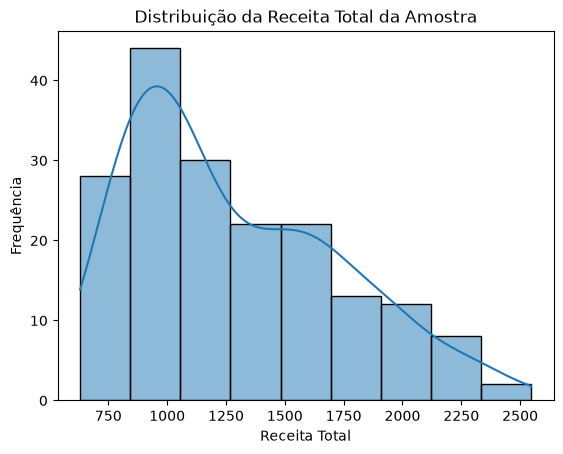

In [54]:
# Visualizando a distribuição da receita total diária da amostra.
sns.histplot(data = df_amostra,
                x = 'receita_total',
                kde = True
                )
plt.title("Distribuição da Receita Total da Amostra")
plt.xlabel("Receita Total")
plt.ylabel("Frequência")
plt.show()

### Explique quais cuidados deveriam ser considerados antes de generalizar os resultados encontrados.

Estamos lidando com uma base de dados limitada pela sazonalidade do primeiro semestre norte americano (inverno/primavera) de três lojas que se encontram em bairros de Nova York com alto fluxo de pessoas e poder aquisitivo. Esses resultados apresentam a realidade desses três bairros que tem uma grande proximidade de características, não sendo possível utilizar essas informações para prever como será o resultado para os meses mais quentes do verão, já que o mix de produtos e o fluxo de clientes pode mudar drasticamente, nem para reproduzir em locais que diferem das características denominadas anteriormente. 


Sabendo que a média de preço dos produtos gira em torno de \$ 3.38 e a quantidade de produtos comprada é de 1.4
podemos assumir o valor de \$ 4.73 por transação. Se considerarmos a quantidade total de transações registrada de 543 e também
a quantidade de observações que utilizamos na amostra de 181, escolhi a quantidade de 200 transações no valor de \$ 4.73 para
realizar a previsão de vendas da cafeteria. 
Portanto, escolhendo o valor hipotético de 200 transações, acredito que o modelo entregará uma predição de receita em torno de $ 946,00. 

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
X = df_diario[['transacoes_totais']]
Y = df_diario['receita_total']

In [57]:
modelo = LinearRegression()
modelo.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4.67]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['transacoes_totais']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.928
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [59]:
print(modelo.intercept_)
print(modelo.coef_[0])

3.9277735748951272
4.672064358947611


In [60]:
modelo.predict([[200]])

c:\Users\glauc\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([938.34064536])

In [ ]:
'''Equação do modelo
 Y = a + bX
 Y = 3.9277735748951272 + 4.672064358947611*200
 Y = 938.34
'''